# Combo analysis plots

Visual companion to `select_composed_neurons.py`. All sections reuse the same
composed-filtered tree so the story stays consistent across plots:

1. **Separation plot** — decision surface (top-2 features) + real points colored by `optimal_value_avg`
2. **Feature importance** — which features actually drive the tree
3. **Full tree diagram** — the splits themselves
4. **Distribution by strategy** — does `composed` really beat `one_variable`/`none`?
5. **Leaf-by-leaf spread** — how tight/reliable is each region's estimate?

Edit `CSV_PATH` below, then Run All.

In [5]:
%matplotlib inline

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from sklearn.tree import DecisionTreeRegressor, plot_tree

## Config

In [7]:
CSV_PATH = "combo_summary.csv"
TARGET_COL = "optimal_value_avg"
FEATURE_COLS = ["l", "u_idx", "k", "j_idx", "LB_neuron1", "UB_neuron1", "LB_neuron2", "UB_neuron2"]
STRATEGY_FILTER = "composed"   # set to None to use every row regardless of strategy
MAX_DEPTH = 4
MIN_LEAF = 3
Z_THRESH = 1.0                  # same "largely superior" cutoff as select_composed_neurons.py

## Load data and rank features

In [8]:
df = pd.read_csv(CSV_PATH)
if STRATEGY_FILTER is not None and "strategy" in df.columns:
    df = df[df["strategy"] == STRATEGY_FILTER].reset_index(drop=True)
print(f"{len(df)} rows after filtering")

X_full = df[FEATURE_COLS].fillna(-1)
y = df[TARGET_COL]

full_tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF, random_state=42)
full_tree.fit(X_full, y)

importances = pd.Series(full_tree.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances

130 rows after filtering


UB_neuron2    0.605010
u_idx         0.387878
LB_neuron1    0.004149
UB_neuron1    0.001597
LB_neuron2    0.001366
j_idx         0.000000
l             0.000000
k             0.000000
dtype: float64

## 1. Separation plot: top-2 features vs. `optimal_value_avg`

In [9]:
feat_x, feat_y = importances.index[0], importances.index[1]
print(f"Plotting on: x = {feat_x}, y = {feat_y}")

X2 = df[[feat_x, feat_y]].fillna(-1)
viz_tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF, random_state=42)
viz_tree.fit(X2, y)

pad_x = 0.05 * ((X2[feat_x].max() - X2[feat_x].min()) or 1)
pad_y = 0.05 * ((X2[feat_y].max() - X2[feat_y].min()) or 1)
xx, yy = np.meshgrid(
    np.linspace(X2[feat_x].min() - pad_x, X2[feat_x].max() + pad_x, 300),
    np.linspace(X2[feat_y].min() - pad_y, X2[feat_y].max() + pad_y, 300),
)
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[feat_x, feat_y])
grid_pred = viz_tree.predict(grid_df).reshape(xx.shape)

cand_pred = viz_tree.predict(X2)
composed_cutoff = cand_pred.mean() + Z_THRESH * cand_pred.std()
print(f"composed cutoff: {composed_cutoff:.4f}")

Plotting on: x = UB_neuron2, y = u_idx
composed cutoff: -3.1503


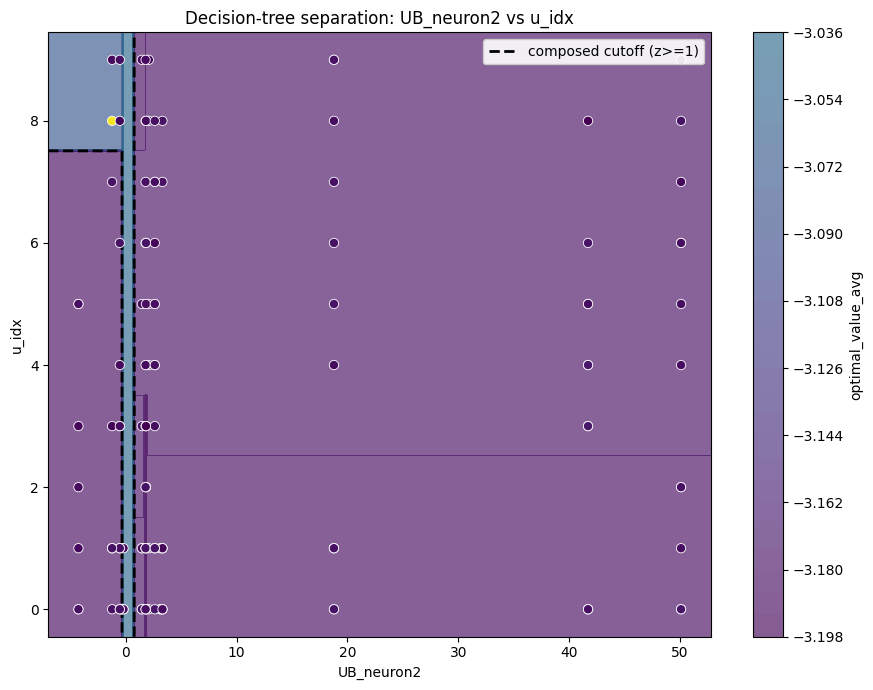

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
norm = Normalize(vmin=min(y.min(), grid_pred.min()), vmax=max(y.max(), grid_pred.max()))
cmap = plt.cm.viridis

background = ax.contourf(xx, yy, grid_pred, levels=30, cmap=cmap, norm=norm, alpha=0.65)
ax.contour(xx, yy, grid_pred, levels=[composed_cutoff], colors="black", linewidths=2, linestyles="--")
ax.scatter(df[feat_x], df[feat_y], c=y, cmap=cmap, norm=norm,
           edgecolors="white", linewidths=0.6, s=45, zorder=3)

cbar = fig.colorbar(background, ax=ax)
cbar.set_label(TARGET_COL)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title(f"Decision-tree separation: {feat_x} vs {feat_y}")

proxy = Line2D([0], [0], color="black", linewidth=2, linestyle="--",
               label=f"composed cutoff (z>={Z_THRESH:g})")
ax.legend(handles=[proxy], loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.savefig("1_separation_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Feature importance

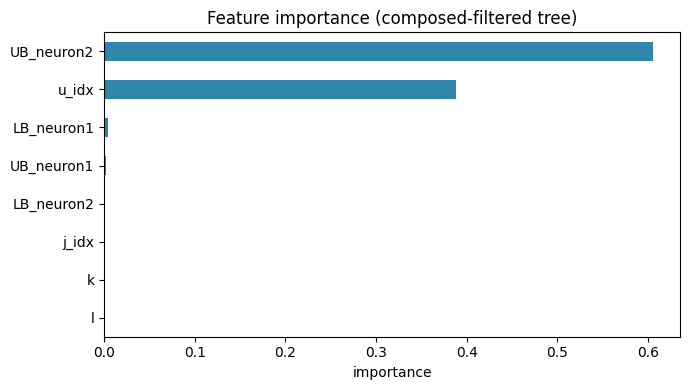

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
importances.sort_values().plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_xlabel("importance")
ax.set_title("Feature importance (composed-filtered tree)")
plt.tight_layout()
plt.savefig("2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Full tree diagram

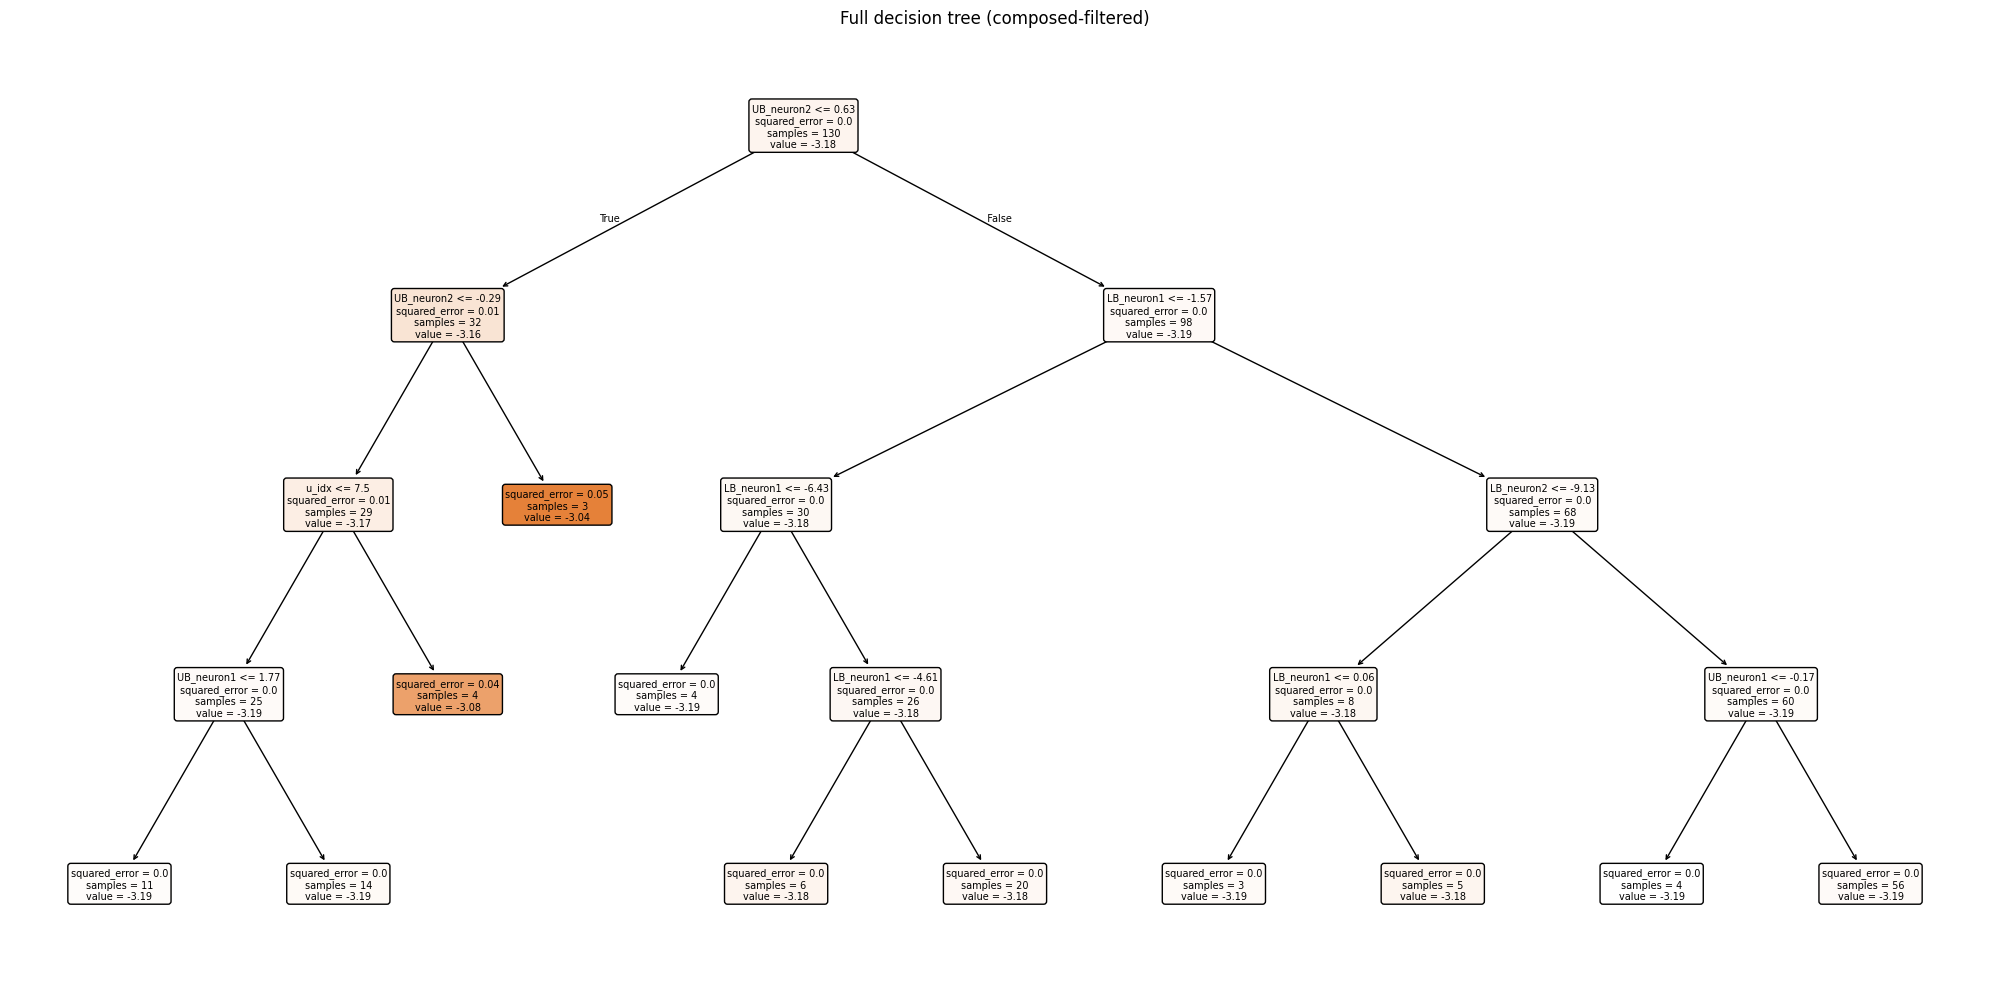

In [12]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(full_tree, feature_names=FEATURE_COLS, filled=True, rounded=True,
          fontsize=7, precision=2, ax=ax)
ax.set_title("Full decision tree (composed-filtered)")
plt.tight_layout()
plt.savefig("3_tree_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Distribution of `optimal_value_avg` by strategy

Uses every row (no composed filter) to compare strategies directly.

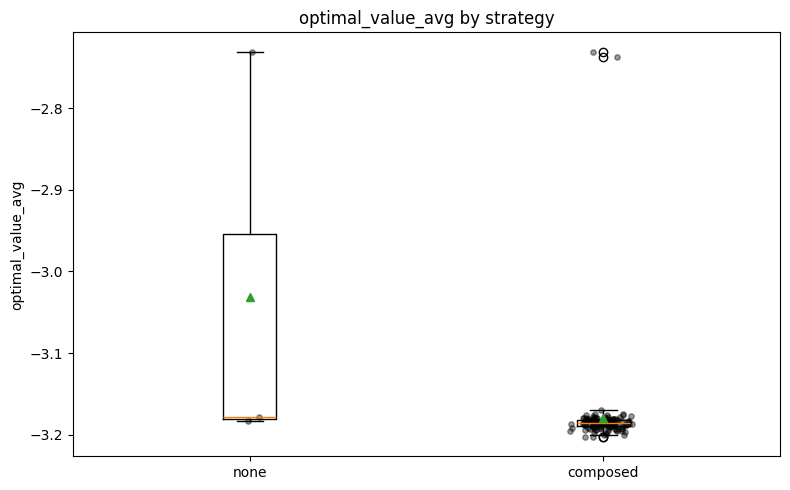

In [13]:
df_all = pd.read_csv(CSV_PATH)
strategies_present = df_all["strategy"].dropna().unique().tolist()

fig, ax = plt.subplots(figsize=(8, 5))
data_by_strategy = [df_all.loc[df_all["strategy"] == s, TARGET_COL].dropna() for s in strategies_present]
ax.boxplot(data_by_strategy, tick_labels=strategies_present, showmeans=True)

rng = np.random.default_rng(0)
for i, s in enumerate(strategies_present, start=1):
    vals = df_all.loc[df_all["strategy"] == s, TARGET_COL].dropna()
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.4, s=15, color="black")

ax.set_ylabel(TARGET_COL)
ax.set_title("optimal_value_avg by strategy")
plt.tight_layout()
plt.savefig("4_by_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Spread of `optimal_value_avg` within each tree leaf

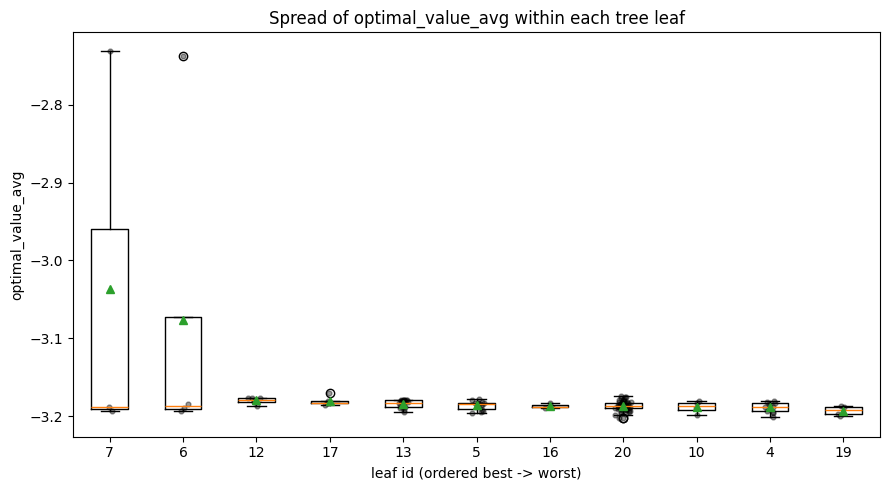

In [14]:
df_leaf = df.copy()
df_leaf["leaf_id"] = full_tree.apply(X_full)
leaf_order = df_leaf.groupby("leaf_id")[TARGET_COL].mean().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(9, 5))
data_by_leaf = [df_leaf.loc[df_leaf["leaf_id"] == lid, TARGET_COL] for lid in leaf_order]
ax.boxplot(data_by_leaf, tick_labels=[str(l) for l in leaf_order], showmeans=True)

rng = np.random.default_rng(0)
for i, lid in enumerate(leaf_order, start=1):
    vals = df_leaf.loc[df_leaf["leaf_id"] == lid, TARGET_COL]
    jitter = rng.normal(0, 0.05, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.4, s=12, color="black")

ax.set_xlabel("leaf id (ordered best -> worst)")
ax.set_ylabel(TARGET_COL)
ax.set_title("Spread of optimal_value_avg within each tree leaf")
plt.tight_layout()
plt.savefig("5_leaf_spread.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Separation plot: UB_neuron2 vs UB_neuron1 (fixed axes)

Same as section 1, but with the two axes pinned to `UB_neuron2`/`UB_neuron1` instead of whichever pair the tree ranks highest -- useful to keep this exact view even if the top-2 importance ranking shifts (e.g. with a different `STRATEGY_FILTER` or a bigger results file).

In [15]:
feat_x, feat_y = "UB_neuron2", "UB_neuron1"
print(f"Plotting on: x = {feat_x}, y = {feat_y}")

X2b = df[[feat_x, feat_y]].fillna(-1)
viz_tree2 = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF, random_state=42)
viz_tree2.fit(X2b, y)

pad_x = 0.05 * ((X2b[feat_x].max() - X2b[feat_x].min()) or 1)
pad_y = 0.05 * ((X2b[feat_y].max() - X2b[feat_y].min()) or 1)
xx2, yy2 = np.meshgrid(
    np.linspace(X2b[feat_x].min() - pad_x, X2b[feat_x].max() + pad_x, 300),
    np.linspace(X2b[feat_y].min() - pad_y, X2b[feat_y].max() + pad_y, 300),
)
grid_df2 = pd.DataFrame(np.c_[xx2.ravel(), yy2.ravel()], columns=[feat_x, feat_y])
grid_pred2 = viz_tree2.predict(grid_df2).reshape(xx2.shape)

cand_pred2 = viz_tree2.predict(X2b)
composed_cutoff2 = cand_pred2.mean() + Z_THRESH * cand_pred2.std()
print(f"composed cutoff: {composed_cutoff2:.4f}")

Plotting on: x = UB_neuron2, y = UB_neuron1
composed cutoff: -3.1503


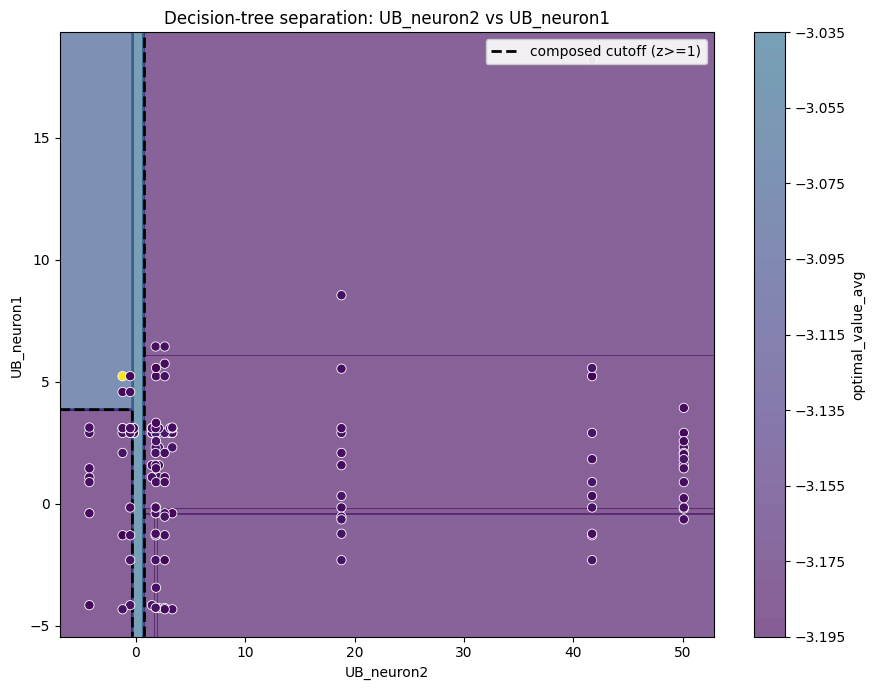

: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
norm2 = Normalize(vmin=min(y.min(), grid_pred2.min()), vmax=max(y.max(), grid_pred2.max()))
cmap = plt.cm.viridis

background2 = ax.contourf(xx2, yy2, grid_pred2, levels=30, cmap=cmap, norm=norm2, alpha=0.65)
ax.contour(xx2, yy2, grid_pred2, levels=[composed_cutoff2], colors="black", linewidths=2, linestyles="--")
ax.scatter(df[feat_x], df[feat_y], c=y, cmap=cmap, norm=norm2,
           edgecolors="white", linewidths=0.6, s=45, zorder=3)

cbar2 = fig.colorbar(background2, ax=ax)
cbar2.set_label(TARGET_COL)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title(f"Decision-tree separation: {feat_x} vs {feat_y}")

proxy2 = Line2D([0], [0], color="black", linewidth=2, linestyle="--",
                label=f"composed cutoff (z>={Z_THRESH:g})")
ax.legend(handles=[proxy2], loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.savefig("6_separation_UBneuron2_UBneuron1.png", dpi=150, bbox_inches="tight")
plt.show()